In [4]:
import os
from pathlib import Path
import time

import pandas as pd
import numpy as np

import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Audio, display

In [5]:
DATASET_DIR = Path("./LibriSpeech/train-clean/19/198")

# Dataset

Dataset Name:
LibriSpeech ASR Corpus

Source:
https://www.openslr.org/12

Reason for Selection

- Standard benchmark dataset for Automatic Speech Recognition
- High-quality English speech
- Human-verified transcripts
- Widely used for evaluating Whisper models

Dataset Contents

- FLAC audio files
- Ground truth transcript file (.trans.txt)

In [6]:
transcript_file = next(DATASET_DIR.glob("*.trans.txt"))

print(transcript_file)

LibriSpeech\train-clean\19\198\19-198.trans.txt


In [7]:
transcripts = {}

with open(transcript_file, "r", encoding="utf-8") as f:

    for line in f:

        parts = line.strip().split(" ", 1)

        file_id = parts[0]

        text = parts[1]

        transcripts[file_id] = text

print("Number of transcripts:", len(transcripts))

Number of transcripts: 38


In [8]:
audio_files = sorted(DATASET_DIR.glob("*.flac"))

print("Number of audio files:", len(audio_files))

Number of audio files: 38


In [9]:
data = []

for file in audio_files:

    file_id = file.stem

    y, sr = librosa.load(file, sr=None)

    duration = len(y) / sr

    data.append({

        "File": file.name,

        "Duration (s)": round(duration,2),

        "Sample Rate": sr,

        "Transcript": transcripts[file_id]

    })

dataset_df = pd.DataFrame(data)

dataset_df.head()

,File,Duration (s),Sample Rate,Transcript
0,19-198-0000.flac,1.97,16000,NORTHANGER ABBEY
1,19-198-0001.flac,11.77,16000,THIS LITTLE WORK WAS FINISHED IN THE YEAR EIGH...
2,19-198-0002.flac,10.79,16000,NEITHER THE AUTHOR NOR THE PUBLIC HAVE ANY OTH...
3,19-198-0003.flac,15.48,16000,THE PUBLIC ARE ENTREATED TO BEAR IN MIND THAT ...
4,19-198-0004.flac,12.99,16000,CHAPTER ONE NO ONE WHO HAD EVER SEEN CATHERINE...


In [10]:
summary = pd.DataFrame({

    "Property":[

        "Dataset",

        "Number of Audio Files",

        "Sample Rate",

        "Average Duration (s)"

    ],

    "Value":[

        "LibriSpeech",

        len(dataset_df),

        dataset_df["Sample Rate"].mode()[0],

        round(dataset_df["Duration (s)"].mean(),2)

    ]

})

summary

,Property,Value
0,Dataset,LibriSpeech
1,Number of Audio Files,38
2,Sample Rate,16000
3,Average Duration (s),13.29


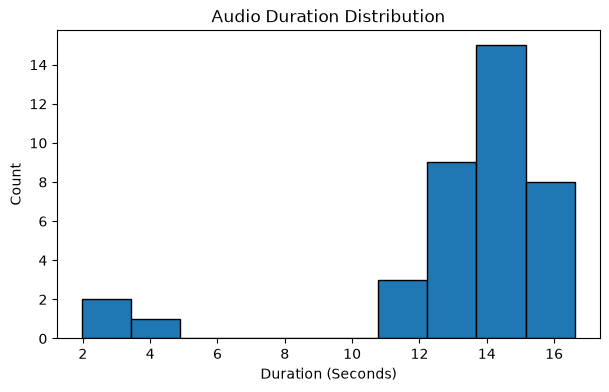

In [11]:
plt.figure(figsize=(7,4))

plt.hist(
    dataset_df["Duration (s)"],
    bins=10,
    edgecolor="black"
)

plt.xlabel("Duration (Seconds)")
plt.ylabel("Count")

plt.title("Audio Duration Distribution")

plt.show()

In [14]:
sample_audio = audio_files[1]

display(Audio(sample_audio))

In [15]:
print(transcripts[sample_audio.stem])

THIS LITTLE WORK WAS FINISHED IN THE YEAR EIGHTEEN O THREE AND INTENDED FOR IMMEDIATE PUBLICATION IT WAS DISPOSED OF TO A BOOKSELLER IT WAS EVEN ADVERTISED


In [16]:
y, sr = librosa.load(sample_audio, sr=16000)

print(y.shape)
print(sr)

(188240,)
16000


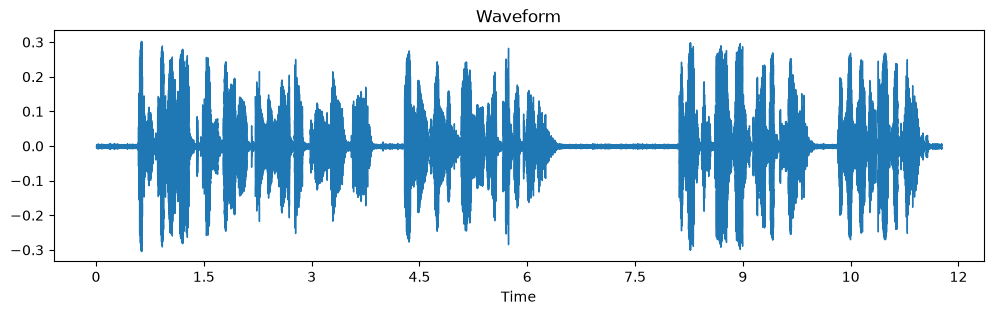

In [17]:
plt.figure(figsize=(12,3))

librosa.display.waveshow(
    y,
    sr=sr
)

plt.title("Waveform")

plt.show()

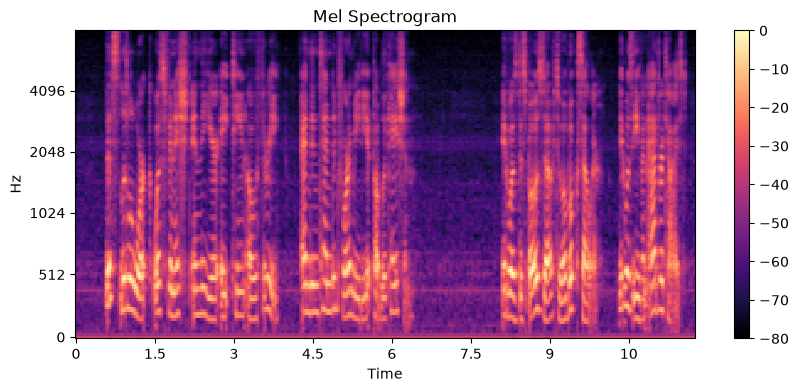

In [18]:
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Mel Spectrogram")

plt.show()

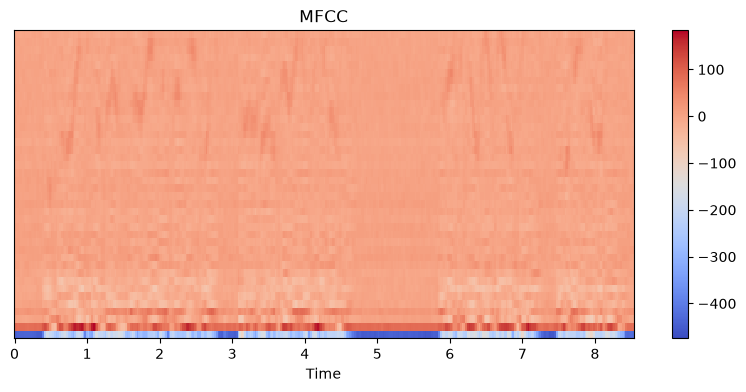

In [19]:
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=40
)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc,
    x_axis="time"
)

plt.colorbar()

plt.title("MFCC")

plt.show()

In [20]:
def preprocess_audio(path):

    audio, sr = librosa.load(

        path,

        sr=16000,

        mono=True

    )

    audio = audio.astype(np.float32)

    return audio

In [21]:
audio = preprocess_audio(sample_audio)

print(audio.shape)

(188240,)


In [22]:
samples = []

for file in audio_files:

    samples.append({

        "audio_path": str(file),

        "reference": transcripts[file.stem]

    })

samples_df = pd.DataFrame(samples)

samples_df.head()

,audio_path,reference
0,LibriSpeech\train-clean\19\198\19-198-0000.flac,NORTHANGER ABBEY
1,LibriSpeech\train-clean\19\198\19-198-0001.flac,THIS LITTLE WORK WAS FINISHED IN THE YEAR EIGH...
2,LibriSpeech\train-clean\19\198\19-198-0002.flac,NEITHER THE AUTHOR NOR THE PUBLIC HAVE ANY OTH...
3,LibriSpeech\train-clean\19\198\19-198-0003.flac,THE PUBLIC ARE ENTREATED TO BEAR IN MIND THAT ...
4,LibriSpeech\train-clean\19\198\19-198-0004.flac,CHAPTER ONE NO ONE WHO HAD EVER SEEN CATHERINE...


In [23]:
print("Total samples:", len(samples_df))

Total samples: 38


In [32]:
import time
import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoModelForSpeechSeq2Seq,
    AutoProcessor,
    pipeline
)

from faster_whisper import WhisperModel

In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cpu


In [34]:
from faster_whisper import WhisperModel

full_model = WhisperModel(
    "tiny",
    device="cpu",
    compute_type="float32"
)

In [35]:
quant_model = WhisperModel(
    "tiny",
    device="cpu",
    compute_type="int8"
)

In [36]:
if device == "cuda":

    quant_model = WhisperModel(
        "tiny",
        device="cuda",
        compute_type="int8_float16"
    )

else:

    quant_model = WhisperModel(
        "tiny",
        device="cpu",
        compute_type="int8"
    )

print("Quantized Whisper Loaded")

Quantized Whisper Loaded


In [37]:
sample = samples_df.iloc[0]

print("Audio File:")
print(sample["audio_path"])

print("\nGround Truth:")
print(sample["reference"])

Audio File:
LibriSpeech\train-clean\19\198\19-198-0000.flac

Ground Truth:
NORTHANGER ABBEY


In [38]:
start = time.perf_counter()

segments, info = full_model.transcribe(
    sample["audio_path"],
    beam_size=5
)

full_text = ""

for segment in segments:
    full_text += segment.text + " "

full_text = full_text.strip()

full_time = time.perf_counter() - start

print(full_text)

Northanger Abbey


In [39]:
start = time.perf_counter()

segments, info = quant_model.transcribe(
    sample["audio_path"],
    beam_size=5
)

quant_text = ""

for segment in segments:
    quant_text += segment.text + " "

quant_text = quant_text.strip()

quant_time = time.perf_counter() - start

print(quant_text)

Northanger Abbey


In [40]:
comparison = pd.DataFrame({

    "Ground Truth":[sample["reference"]],

    "Full Model":[full_text],

    "Quantized Model":[quant_text]

})

comparison

,Ground Truth,Full Model,Quantized Model
0,NORTHANGER ABBEY,Northanger Abbey,Northanger Abbey


In [41]:
full_predictions = []
full_times = []

for _, row in samples_df.iterrows():

    start = time.perf_counter()

    segments, info = full_model.transcribe(
        row["audio_path"],
        beam_size=5
    )

    prediction = ""

    for segment in segments:
        prediction += segment.text + " "

    prediction = prediction.strip()

    elapsed = time.perf_counter() - start

    full_predictions.append(prediction)

    full_times.append(elapsed)

In [42]:
quant_predictions = []
quant_times = []

for _, row in samples_df.iterrows():

    start = time.perf_counter()

    segments, info = quant_model.transcribe(
        row["audio_path"],
        beam_size=5
    )

    prediction = ""

    for segment in segments:
        prediction += segment.text + " "

    prediction = prediction.strip()

    elapsed = time.perf_counter() - start

    quant_predictions.append(prediction)

    quant_times.append(elapsed)

In [43]:
samples_df["Full Prediction"] = full_predictions
samples_df["Quantized Prediction"] = quant_predictions

samples_df["Full Time (s)"] = full_times
samples_df["Quantized Time (s)"] = quant_times

samples_df.head()

,audio_path,reference,Full Prediction,Quantized Prediction,Full Time (s),Quantized Time (s)
0,LibriSpeech\train-clean\19\198\19-198-0000.flac,NORTHANGER ABBEY,Northanger Abbey,Northanger Abbey,0.850083,0.678982
1,LibriSpeech\train-clean\19\198\19-198-0001.flac,THIS LITTLE WORK WAS FINISHED IN THE YEAR EIGH...,This little work was finished in the year 1803...,This little work was finished in the year 1803...,1.181720,0.762969
2,LibriSpeech\train-clean\19\198\19-198-0002.flac,NEITHER THE AUTHOR NOR THE PUBLIC HAVE ANY OTH...,Neither the author nor the public have any oth...,Neither the author nor the public have any oth...,1.248715,0.693316
3,LibriSpeech\train-clean\19\198\19-198-0003.flac,THE PUBLIC ARE ENTREATED TO BEAR IN MIND THAT ...,The public are untreated to bear in mind that ...,The public are intruded to bear in mind that 1...,1.035132,0.754121
4,LibriSpeech\train-clean\19\198\19-198-0004.flac,CHAPTER ONE NO ONE WHO HAD EVER SEEN CATHERINE...,Chapter 1. No one who had ever seen Catherine...,Chapter 1. No one who had ever seen Katharine...,1.389873,0.714686


In [44]:
avg_full = np.mean(full_times)
avg_quant = np.mean(quant_times)

runtime_df = pd.DataFrame({

    "Model":[
        "Full Whisper",
        "Quantized Whisper"
    ],

    "Average Time (s)":[
        avg_full,
        avg_quant
    ]

})

runtime_df

,Model,Average Time (s)
0,Full Whisper,1.193745
1,Quantized Whisper,0.731725


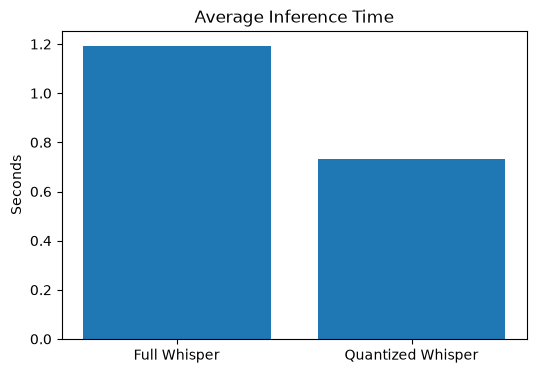

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    runtime_df["Model"],
    runtime_df["Average Time (s)"]
)

plt.ylabel("Seconds")
plt.title("Average Inference Time")

plt.show()

In [47]:
for i in range(min(5, len(samples_df))):

    print("="*80)

    print("Ground Truth")
    print(samples_df.iloc[i]["reference"])

    print("\nFull Model")
    print(samples_df.iloc[i]["Full Prediction"])

    print("\nQuantized Model")
    print(samples_df.iloc[i]["Quantized Prediction"])

    print()

Ground Truth
NORTHANGER ABBEY

Full Model
Northanger Abbey

Quantized Model
Northanger Abbey

Ground Truth
THIS LITTLE WORK WAS FINISHED IN THE YEAR EIGHTEEN O THREE AND INTENDED FOR IMMEDIATE PUBLICATION IT WAS DISPOSED OF TO A BOOKSELLER IT WAS EVEN ADVERTISED

Full Model
This little work was finished in the year 1803 and intended for immediate publication.  It was disposed of to a bookseller. It was even advertised.

Quantized Model
This little work was finished in the year 1803 and intended for immediate publication.  It was disposed of to a bookseller. It was even advertised.

Ground Truth
NEITHER THE AUTHOR NOR THE PUBLIC HAVE ANY OTHER CONCERN THAN AS SOME OBSERVATION IS NECESSARY UPON THOSE PARTS OF THE WORK WHICH THIRTEEN YEARS HAVE MADE COMPARATIVELY OBSOLETE

Full Model
Neither the author nor the public have any other concern that as some observation is necessary  upon those parts of the work which 13 years have made comparatively obsolete.

Quantized Model
Neither the autho

In [48]:
samples_df.to_csv(
    "transcription_results.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [49]:
from jiwer import wer, cer

import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
from jiwer import wer, cer

references = samples_df["reference"].tolist()

full_predictions = samples_df["Full Prediction"].tolist()

quant_predictions = samples_df["Quantized Prediction"].tolist()

full_wer = wer(references, full_predictions)
quant_wer = wer(references, quant_predictions)

full_cer = cer(references, full_predictions)
quant_cer = cer(references, quant_predictions)

print(f"Full Model WER: {full_wer:.4f}")
print(f"Quantized Model WER: {quant_wer:.4f}")

print(f"Full Model CER: {full_cer:.4f}")
print(f"Quantized Model CER: {quant_cer:.4f}")

Full Model WER: 1.0041
Quantized Model WER: 1.0057
Full Model CER: 0.8463
Quantized Model CER: 0.8479
